# Logistic Regression for Anomaly Detection

This notebook implements Logistic Regression to identify anomalous users in a recommender system dataset.

### Pipeline Overview
1. Load and inspect data
2. Build per-user feature vectors (pivot to user × item rating matrix)
3. Reduce dimensionality with TruncatedSVD (handles sparsity well)
4. Train Logistic Regression with class balancing
5. Evaluate with AUC, Precision, Recall, F1
6. Generate and save anomaly scores for submission

## 1. Imports & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, IsolationForest
import os

# Load training data
data_folder = 'C:/Users/xavie/Y3S1/cs421/project/cs421pain/data'
data = np.load(os.path.join(data_folder, "training_batch_with_labels.npz"))
X_raw = data["X"]   # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]   # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")


Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


In [2]:
# load first_batch_with_labels.npz
data_2 = np.load(os.path.join(data_folder, 'first_batch_with_labels.npz'))
X = data_2['X']
y = data_2['y']
print(f"Interactions : {X.shape[0]:,}")
print(f"Users        : {len(np.unique(X[:, 0]))}")
print(f"Items        : {len(np.unique(X[:, 1]))}")
print(f"Anomalous    : {np.sum(y[:, 1] == 1)}")
print(f"Normal       : {np.sum(y[:, 1] == 0)}")

Interactions : 167,493
Users        : 1100
Items        : 989
Anomalous    : 100
Normal       : 1000


In [3]:
# combine the two datasets
print(type(X))
print(type(y))

# combine np arrays
X_raw = np.concatenate((X, X_raw), axis=0)
y_raw = np.concatenate((y, y_raw), axis=0)
print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")



<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Interactions : 344,839
Users        : 2200
Items        : 996
Anomalous    : 200
Normal       : 2000


In [4]:
RUN_DESC = 'testing item-deviation features + item-entropy + rating distribution shape + gini-coef'

In [ ]:
# ── Shared handcrafted-feature definition ────────────────────────────────────
# ▼▼▼ EDIT HERE to change features — this is the ONLY place you need to touch ▼▼▼

def compute_handcrafted_features(df, recon_error=None):
    """
    Given a DataFrame with columns [user, item, rating], compute and return
    a per-user feature DataFrame (index = user id).

    Parameters
    ----------
    df           : pd.DataFrame  [user, item, rating]
    recon_error  : pd.Series or None
        Per-user SVD reconstruction error (index = user id), pre-computed
        from a TruncatedSVD fit on the user-item matrix.  When provided it
        is appended as the last feature column.  Pass None to omit it.

    This is the single source of truth for all handcrafted features.
    Both the CV evaluation (cell 'feature-engineering') and the final
    submission builder (cell 'generate-submission') call this function,
    so changes here propagate automatically to both.
    """
    # --- derived columns (add any new ones here) ----------------------------
    item_means        = df.groupby("item")["rating"].mean()
    df = df.copy()  # avoid mutating the caller's DataFrame
    df["deviation"]   = df["rating"] - df["item"].map(item_means)

    # # calculate the number of unique items rated per user, append as column
    # df["num_items"] = df.groupby('user')['item'].nunique()
    # # total num of ratings per user, append as column
    # df["num_ratings"] = df.groupby('user')['rating'].transform('count')

    # --- aggregated per-user features (add / remove / comment out freely) ---
    agg = df.groupby("user").agg(
        num_ratings    = ("rating",    "count"),
        mean_rating    = ("rating",    "mean"),
        std_rating     = ("rating",    "std"),
        num_items      = ("item",      "nunique"),
        pct_extreme    = ("rating",    lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero       = ("rating",    lambda r: (r == 0).mean()),
        pct_five       = ("rating",    lambda r: (r == 5).mean()),
        # # Rating distribution shape
        rating_skewness   = ("rating", lambda r: r.skew()),
        rating_kurtosis   = ("rating", lambda r: r.kurtosis()),
        median_rating     = ("rating", "median"),
        # Item concentration — anomalies often target a narrow set of items
        item_entropy      = ("item",   lambda x: -(pd.Series(x.value_counts(normalize=True))
                                                    * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)).sum()),
        # Item-deviation features
        mean_deviation = ("deviation", "mean"),
        std_deviation  = ("deviation", "std"),
        abs_deviation  = ("deviation", lambda x: x.abs().mean()),

        # additional handcrafted features
        gini_items = ('item', lambda x: 1 - sum((pd.Series(x).value_counts(normalize=True))**2)),
        pct_low    = ('rating', lambda r: (r < 3).mean()),
        # # ratio of of unique items to total ratings
        # item_diversity_ratio = ('item',  lambda df: df['num_items'] / df['num_ratings']), 

        # how quickly the user rated things
        rating_velocity = ("rating", lambda r: len(r) / (r.index.nunique() + 1))
        
    ).fillna(0)

    # --- SVD reconstruction error (appended last if provided) ---------------
    if recon_error is not None:
        agg["recon_error"] = recon_error.reindex(agg.index).fillna(0)

    return agg

# ▲▲▲ end of editable section ▲▲▲


## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [ ]:
# ── Build per-user feature matrix ──────────────────────────────────────────

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

# Pivot: rows = users, columns = items, values = rating (NaN → 0)
user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0)

# Align labels to the same user order
labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# ── SVD reconstruction error ────────────────────────────────────────────────
# Fit a TruncatedSVD on the full training user-item matrix to learn the
# low-rank approximation of normal behaviour.  The per-user reconstruction
# error (MSE of the residual) captures how far each user deviates from the
# normal-behaviour manifold — anomalous users are poorly approximated and
# will have large residuals.
#
# This SVD is fit outside the pipeline so the reconstruction error can be
# appended as a plain feature column.  The pipeline's internal SVDPlusHandcrafted
# then performs a *second*, independent SVD compression on the user-item block
# for the logistic regression embedding — these are separate roles.
#
# N_RECON_COMPONENTS controls how many singular vectors define "normal".
# Fewer components → coarser normal model → easier for anomalies to stand out.
# Start at 30–50 and tune alongside N_COMPONENTS.
N_RECON_COMPONENTS = 30

_recon_svd = TruncatedSVD(n_components=N_RECON_COMPONENTS, random_state=42)
_ui_vals   = user_item.values                           # (n_users, n_items)
_approx    = _recon_svd.fit_transform(_ui_vals)         # (n_users, k)
_approx    = _approx @ _recon_svd.components_           # reconstruct: (n_users, n_items)
_residuals = _ui_vals - _approx                         # element-wise error
recon_error_train = pd.Series(
    np.mean(_residuals ** 2, axis=1),                   # per-user MSE
    index=user_item.index,
    name="recon_error",
)

print(f"\nReconstruction error — mean: {recon_error_train.mean():.4f} "
      f"std: {recon_error_train.std():.4f}")

normal_mask = (y == 0)
mean_normal_vec = user_item.values[normal_mask].mean(axis=0, keepdims=True)

cos_sim = cosine_similarity(user_item.values, mean_normal_vec).ravel()
cos_sim_series = pd.Series(cos_sim, index=user_item.index, name="cos_sim_to_normal")

# ── Handcrafted features (defined in 'shared-feature-fn' cell above) ────────
agg = compute_handcrafted_features(interactions, recon_error=recon_error_train)
agg = agg.loc[user_item.index]   # align FIRST — drop any users not in user_item
agg["cos_sim_to_normal"] = cos_sim_series.reindex(agg.index)

print("\nHandcrafted features:")
print(agg.head())


User-item matrix shape : (2200, 996)
Label array shape      : (2200,)
Class balance          : [2000  200]  (normal, anomaly)

Reconstruction error — mean: 0.7597 std: 0.3916

Handcrafted features:
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  rating_skewness  rating_kurtosis  median_rating  item_entropy  \
user                                                                            
100   0.068182        -0.955265         0.852420            3.0      6.459431  

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [7]:
# ── Custom transformer: applies SVD to user-item block only ─────────────────
# The handcrafted features (mean_rating, pct_extreme, recon_error, etc.) are
# already compact and meaningful — running SVD over them would corrupt their
# signal.  This transformer splits the matrix, compresses only the user-item
# block, then re-concatenates the handcrafted columns unchanged.
#
# Note: the SVD here is a separate, independent compression used to build the
# low-dimensional embedding fed to logistic regression.  It is distinct from
# the reconstruction-error SVD fit in the feature-engineering cell above.

N_HANDCRAFTED = agg.shape[1]  # auto-updated when features are added/removed

class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """Applies TruncatedSVD to the user-item block; passes handcrafted features through."""
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED])  # fit on user-item block only
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hand_part = X[:, -N_HANDCRAFTED:]     # handcrafted columns passed through
        return np.hstack([svd_part, hand_part])

# ── Combine raw user-item matrix + handcrafted features (NO SVD applied yet) ─
# SVD is now inside the pipeline so GridSearchCV can tune n_components
X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  └─ user-item columns : {user_item.shape[1]}")
print(f"  └─ handcrafted cols  : {N_HANDCRAFTED}")
print(f"       (includes recon_error as the last column)")


Raw combined feature matrix shape : (2200, 1013)
  └─ user-item columns : 996
  └─ handcrafted cols  : 17
       (includes recon_error as the last column)


## 4. Logistic Regression Model

Key design choices:
- **`class_weight='balanced'`** — automatically up-weights the rare anomaly class (100 vs 1000 users), preventing the model from ignoring anomalies.
- **StandardScaler** — logistic regression is sensitive to feature scale.
- **`solver='lbfgs'`** with L2 regularisation — stable for this size.
- **Stratified 5-fold CV** — preserves class ratio in each fold; gives reliable AUC estimates on an imbalanced dataset.

In [ ]:
N_COMPONENTS = 30
pipeline = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),  # SVD inside pipeline — now tunable
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight="balanced",  # handles 10:1 imbalance
                   max_iter=1000,
                   solver="lbfgs",
                   C=1.0,
                   random_state=42
               ))
])

gbm = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=80)),
    ("scaler", StandardScaler()),
    ("clf", GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                        subsample=0.8, random_state=42))
])
ensemble = VotingClassifier([("lr", lr), ("gbm", gbm)], voting="soft")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# X_raw_combined is used from here on (replaces X_features)
y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y,
    cv=cv, method="predict_proba"
)[:, 1]

# ── Find the threshold that maximises F1 (instead of using a fixed 0.5) ────
from sklearn.metrics import precision_recall_curve as _prc
_prec, _rec, _thresh = _prc(y, y_scores_cv)
_f1_scores = np.where(
    (_prec[:-1] + _rec[:-1]) > 0,
    2 * _prec[:-1] * _rec[:-1] / (_prec[:-1] + _rec[:-1]),
    0
)
best_f1_threshold = float(_thresh[np.argmax(_f1_scores)])
print(f"Best F1 threshold (used for classification): {best_f1_threshold:.4f}")

y_pred_cv = (y_scores_cv >= best_f1_threshold).astype(int)

print("=== Cross-validated Performance ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print()
print(classification_report(y, y_pred_cv, target_names=["Normal", "Anomaly"]))


Best F1 threshold (used for classification): 0.8322
=== Cross-validated Performance ===
AUC       : 0.9735
Precision : 0.7789
Recall    : 0.7750
F1        : 0.7769

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      2000
     Anomaly       0.78      0.78      0.78       200

    accuracy                           0.96      2200
   macro avg       0.88      0.88      0.88      2200
weighted avg       0.96      0.96      0.96      2200



## 5. ROC Curve

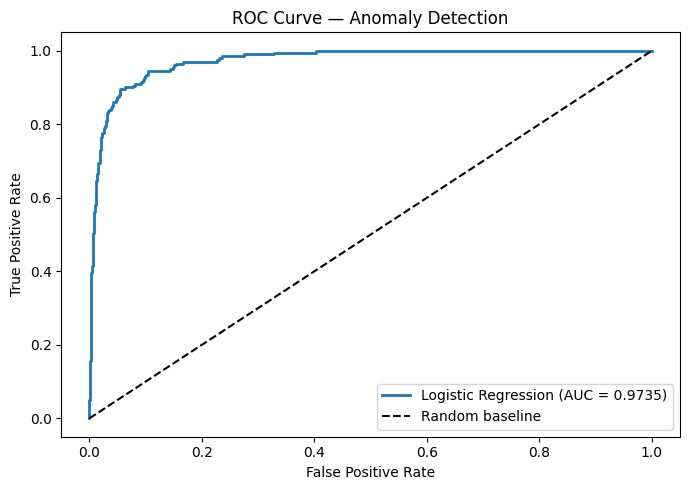

In [9]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

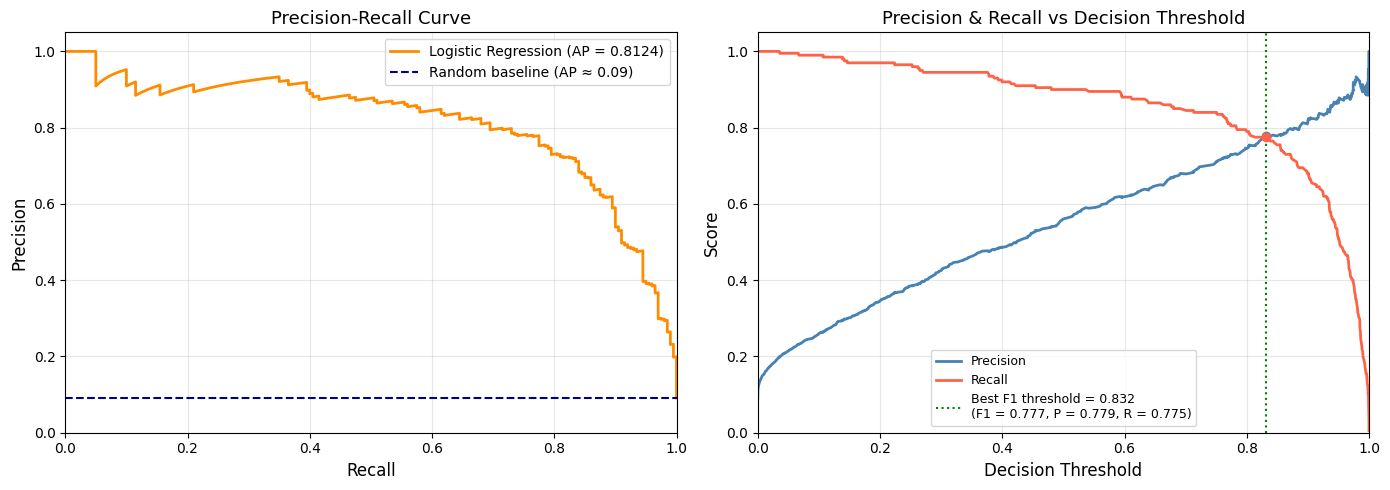

Average Precision (AP)  : 0.8124
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 8.9x

Best F1 threshold : 0.832
  Precision       : 0.7789
  Recall          : 0.7750
  F1              : 0.7769


In [10]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [11]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    1.0000    1.0000
            0.1          0.1000    0.9091    0.9987
            0.2          0.2000    0.9091    0.9902
            0.3          0.3000    0.9231    0.9844
            0.4          0.4000    0.8889    0.9731
            0.5          0.5000    0.8772    0.9519
            0.6          0.6000    0.8451    0.9350
            0.7          0.7000    0.7955    0.8828
            0.8          0.8000    0.7306    0.7828
            0.9          0.9000    0.5389    0.4802
            1.0          1.0000    0.0909    0.0000


In [12]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF',  size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79',  size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623',  size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1

# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lr_C      = float(pipeline.named_steps['lr'].C)
run_label_short = f'Run {{run_num}}'  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == 'CV Performance']
run_num = 1
if 'CV Performance' in wb.sheetnames:
    ws_check = wb['CV Performance']
    # count data rows (skip header row 1)
    run_num = sum(
        1 for row in ws_check.iter_rows(min_row=2, max_col=1)
        if row[0].value is not None
    ) + 1

run_header_text = (
    f'Run {run_num}  |  {run_ts}  '
    f'|  C={lr_C}  |  SVD components={N_COMPONENTS}'
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val  = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val  = recall_score(y, y_pred_cv)
f1_val   = f1_score(y, y_pred_cv)
report   = classification_report(
    y, y_pred_cv, target_names=['Normal', 'Anomaly'], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr  = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ('Run',                  8,   '0',       lambda: run_num),
    ('Timestamp',           22,   '@',       lambda: run_ts),
    ('C (regularisation)',  20,   '0.####',  lambda: lr_C),
    ('SVD Components',      16,   '0',       lambda: N_COMPONENTS),
    ('AUC',                 10,   '0.0000',  lambda: auc_val),
    ('Precision @0.5',      14,   '0.0000',  lambda: prec_val),
    ('Recall @0.5',         13,   '0.0000',  lambda: rec_val),
    ('F1 @0.5',             10,   '0.0000',  lambda: f1_val),
    ('AP (PR curve)',        14,   '0.0000',  lambda: ap),
    ('Best-F1 Threshold',   18,   '0.0000',  lambda: best_thresh),
    ('Best-F1 Score',       14,   '0.0000',  lambda: best_f1_pr),
    ('Normal Precision',    16,   '0.0000',  lambda: report['Normal']['precision']),
    ('Normal Recall',       14,   '0.0000',  lambda: report['Normal']['recall']),
    ('Anomaly Precision',   17,   '0.0000',  lambda: report['Anomaly']['precision']),
    ('Anomaly Recall',      15,   '0.0000',  lambda: report['Anomaly']['recall']),
    ('Macro Avg Precision', 19,   '0.0000',  lambda: report['macro avg']['precision']),
    ('Macro Avg Recall',    17,   '0.0000',  lambda: report['macro avg']['recall']),
    ('Description',         40,   '@',       lambda: RUN_DESC),
]

if 'CV Performance' in wb.sheetnames:
    ws1 = wb['CV Performance']
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet('CV Performance')
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = (run_num % 2 == 0)
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ('False Positive Rate', 22),
    ('True Positive Rate',  22),
    ('Threshold',           18),
    ('Notes',               36),
]

if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2  = next_append_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2+1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx  = np.round(np.linspace(0, len(fpr)-1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri  = r2 + 2 + offset
    alt = (offset % 2 == 1)
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f'AUC={auc_val:.4f} — origin point (no threshold)' if offset == 0 else ''
    style_body(ws2.cell(ri, 4), note, alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ('Recall',    16),
    ('Precision', 14),
    ('Threshold', 14),
    ('F1 Score',  12),
]

if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3  = next_append_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c_sum = ws3.cell(r3+1, 1)
c_sum.value = (
    f'AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold={best_thresh:.3f} '
    f'(F1={best_f1_pr:.4f}, '
    f'P={precision_vals[best_pr_idx]:.4f}, '
    f'R={recall_vals[best_pr_idx]:.4f})'
)
c_sum.font = Font(name='Arial', size=9)
c_sum.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ('Recall (target)', 16),
    ('Recall (actual)', 16),
    ('Precision',       14),
    ('Threshold',       14),
]
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table — fixed recall levels 0.0 to 1.0')
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3+3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2  = int(np.argmin(np.abs(recall_vals - target_r)))
    th2   = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt   = (s_off % 2 == 1)
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f'A{sb}:D{sb}')
style_section(ws3.cell(sb, 1), 'Full PR Curve — downsampled to 100 points')
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb+1, col_i), label)

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri  = sb + 2 + p_off
    alt = (p_off % 2 == 1)
    denom = precision_vals[pi] + recall_vals[pi]
    f1v   = float(2*precision_vals[pi]*recall_vals[pi]/denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})')


performance_results.xlsx updated — Run 13 appended (2026-03-23 21:10:56)


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

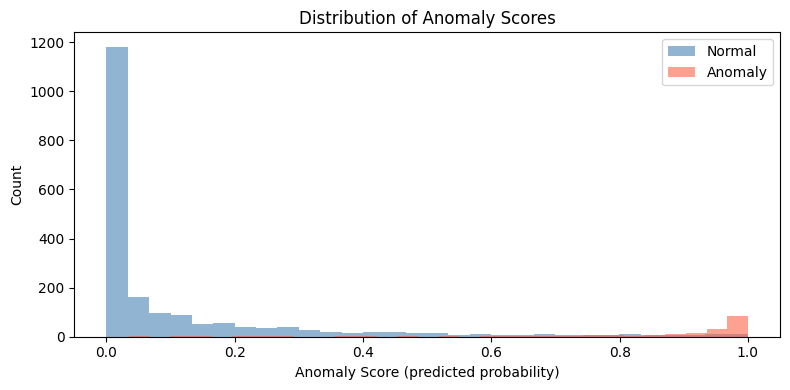

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [14]:
# ── Fit on ALL training data ────────────────────────────────────────────────
pipeline.fit(X_raw_combined, y)
print("Final model trained on full training set.")


Final model trained on full training set.


In [15]:
# ── Helper: build RAW combined features for any interaction batch ────────────
# Uses compute_handcrafted_features() so changes there apply here automatically.
# Reconstruction error is computed using the SVD fit on the training data
# (_recon_svd, user_item.columns) so test users are scored against the same
# low-rank model of normal behaviour.

def build_features_raw(X_interactions, all_items, recon_svd):
    """
    Parameters
    ----------
    X_interactions : np.ndarray, shape (n, 3)  — [user_id, item_id, rating]
    all_items      : item index from training (ensures consistent column order)
    recon_svd      : fitted TruncatedSVD used for reconstruction-error feature

    Returns
    -------
    X_combined : np.ndarray, shape (n_users, n_items + n_handcrafted)
    users      : list of user ids in row order
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    # Reconstruction error against the training low-rank model
    _approx    = recon_svd.transform(pivot.values) @ recon_svd.components_
    _residuals = pivot.values - _approx
    recon_err  = pd.Series(
        np.mean(_residuals ** 2, axis=1),
        index=pivot.index,
        name="recon_error",
    )

    agg_new = compute_handcrafted_features(df, recon_error=recon_err).loc[pivot.index]

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


# ── Score the test batch ──────────────────────────────────────────────────────
data_test  = np.load(os.path.join(data_folder, "second_batch.npz"))
X_test_raw = data_test["X"]

all_items = user_item.columns.tolist()  # item index from training

X_test_combined, test_users = build_features_raw(X_test_raw, all_items, _recon_svd)

# Use best_pipeline if grid search was run, otherwise use pipeline
score_pipeline = best_pipeline if 'best_pipeline' in dir() else pipeline
anomaly_scores = score_pipeline.predict_proba(X_test_combined)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

# ── Save submission ───────────────────────────────────────────────────────────
np.savez("submission_lr.npz", predictions=anomaly_scores)
print("\nsubmission_lr.npz saved!")


Scored 860 users
Score range  : [0.0000, 1.0000]
Mean score   : 0.1776

submission_lr.npz saved!


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [17]:
from sklearn.model_selection import GridSearchCV

# Search over both SVD dimensionality and regularisation strength.
# n_components is now tunable because SVDPlusHandcrafted sits inside the pipeline.
# Scoring is F1 (anomaly class) — the metric we wish to optimise.
param_grid = {
    "svd_hc__n_components": [i for i in range(30, 160, 10)],
    "lr__C":                [0.001, 0.01, 0.1, 1.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring={
        "F1": "f1",
        "ROC_AUC": "roc_auc"
    },          # optimise F1 score (anomaly = positive class)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit="ROC_AUC"   # automatically refits best params on the full dataset
)

grid_search.fit(X_raw_combined, y)

print(f"Best n_components : {grid_search.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_search.best_params_['lr__C']}")
print(f"Best ROC_AUC      : {grid_search.best_score_:.4f}")  # best_score_ reflects refit metric (ROC_AUC)

results = pd.DataFrame(grid_search.cv_results_)
print(results[
    [
        "param_svd_hc__n_components",
        "param_lr__C",
        "mean_test_F1",       
        "std_test_F1",        
        "mean_test_ROC_AUC",  # bonus: view both metrics side by side
        "rank_test_F1",
    ]
].sort_values("mean_test_F1", ascending=False).head(10).to_string(index=False))

best_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 52 candidates, totalling 260 fits
Best n_components : 30
Best C            : 1.0
Best ROC_AUC      : 0.9743
 param_svd_hc__n_components  param_lr__C  mean_test_F1  std_test_F1  mean_test_ROC_AUC  rank_test_F1
                         40          1.0      0.698161     0.044200           0.973425             1
                         50          1.0      0.697293     0.051094           0.971450             2
                         30          1.0      0.693114     0.053474           0.974338             3
                         60          1.0      0.685867     0.067600           0.968437             4
                         90          1.0      0.679126     0.036876           0.958975             5
                         70          1.0      0.677519     0.040352           0.967325             6
                        100          1.0      0.676384     0.040833           0.957388             7
                        120          1.0      0.675644  